ГАРМОНИЧЕСКИЙ СИГНАЛ 440 Гц
  Шаг решетки: 20 см
  Частота сигнала: 440 Гц
  Угол источника: 30°
  SNR: 30 дБ
Координаты микрофонов: [-0.7 -0.5 -0.3 -0.1  0.1  0.3  0.5  0.7]
Размерность X: (8, 24000)
Теоретическая задержка (крайние): 0.002059 с
СРАВНЕНИЕ ТЕОРЕТИЧЕСКИХ И ОЦЕНЕННЫХ ЗАДЕРЖЕК
Микрофон   Теоретическая (мс)   Оцененная (мс)       Ошибка (мс)    
2          0.2941               1.5632               1.2691         
3          0.5882               3.8739               3.2856         
4          0.8824               -0.3094              1.1917         
5          1.1765               1.4345               0.2580         
6          1.4706               -3.1453              4.6159         
7          1.7647               -4.9381              6.7028         
8          2.0588               2.3965               0.3377         
Средняя ошибка: 2.5230 мс
Максимальная ошибка: 6.7028 мс

ОЦЕНКА УГЛА:
  Истинный угол: 30°
  Оцененный угол: 35.59°
  Ошибка: 5.59°


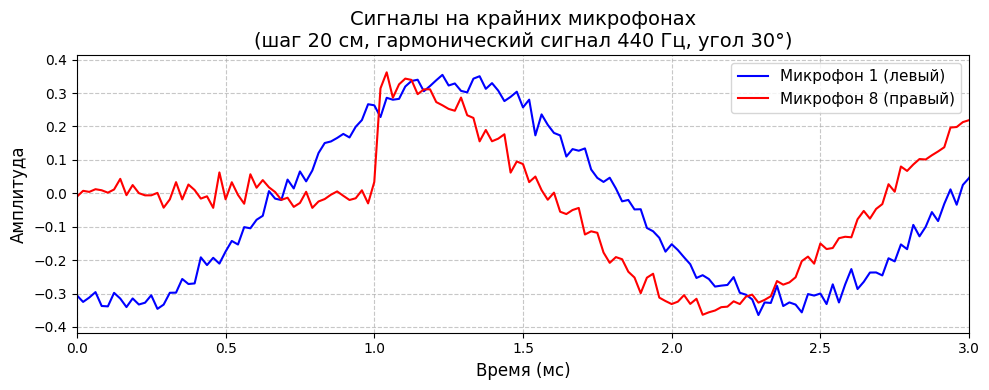

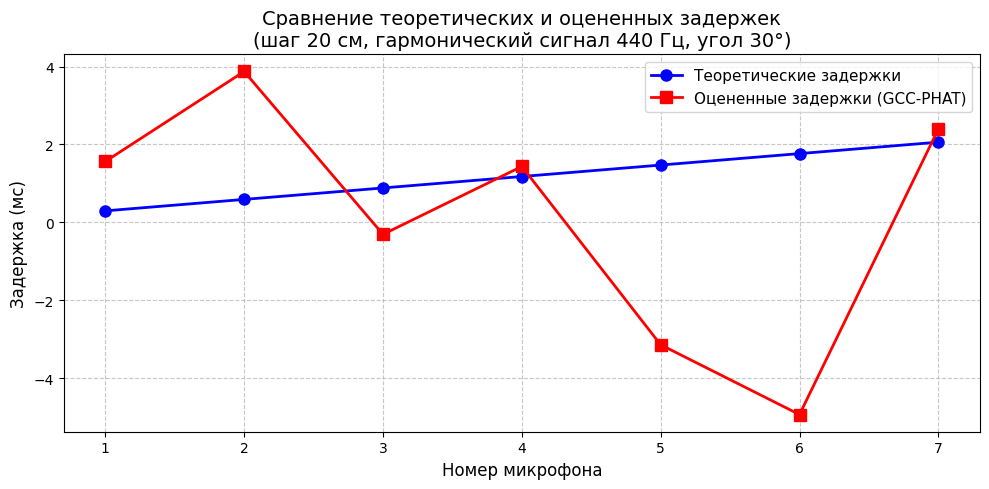


Данные для рисунка:
  Истинная задержка: 2.059 мс
  Найденный пик: 2.396 мс
  Ошибка пика: 0.337 мс


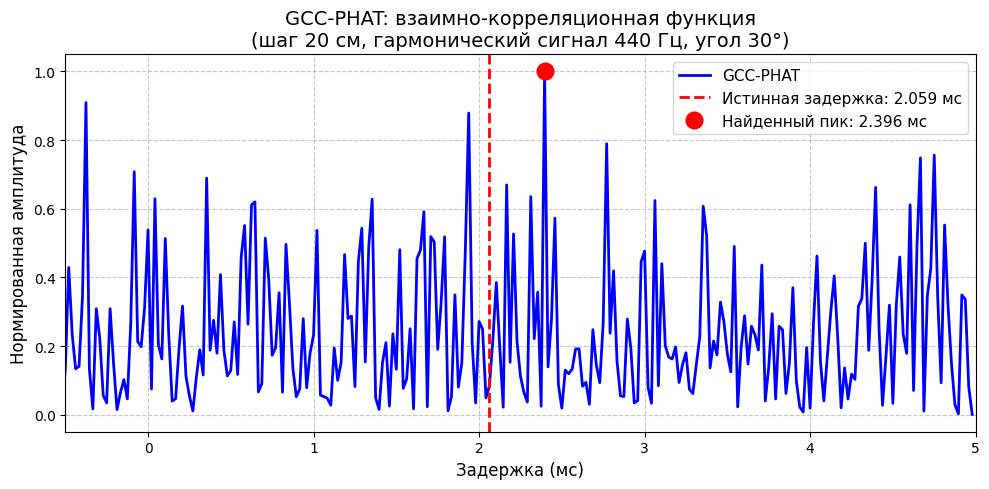

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import rfft, irfft

np.random.seed(42)

# 1. Генерация сигнала

def generate_harmonic_signal(fs, T, f0, A=1.0):
    t = np.arange(0, T, 1/fs)
    s = A * np.cos(2 * np.pi * f0 * t)
    return t, s

def generate_array_signals(s, t, d, theta, R=3.0, SNR_dB=30, c=340, fs=None):
    M = len(d)
    L = len(s)
    theta_rad = np.deg2rad(theta)
    tau = d * np.sin(theta_rad) / c

    tau_samples = tau * fs
    delay_samples = np.round(tau_samples).astype(int)

    attenuation = 1.0 / R
    X = np.zeros((M, L))

    for m in range(M):
        s_delayed = np.zeros_like(s)
        delay = delay_samples[m]

        if delay >= 0:
            if delay > 0:
                s_delayed[delay:] = s[:-delay]
            else:
                s_delayed[:] = s[:]
        else:
            delay_abs = abs(delay)
            if delay_abs > 0:
                s_delayed[:-delay_abs] = s[delay_abs:]
            else:
                s_delayed[:] = s[:]

        signal_power = np.mean(s_delayed**2)
        if signal_power < 1e-12:
            signal_power = 1.0
        noise_power = signal_power / (10**(SNR_dB/10))
        noise = np.sqrt(noise_power) * np.random.randn(L)

        X[m, :] = attenuation * s_delayed + noise

    return X, tau

# 2. GCC-PHAT

def gcc_phat_interp(signal1, signal2, fs, max_delay_ms=5):
    signal1 = np.nan_to_num(signal1, nan=0.0)
    signal2 = np.nan_to_num(signal2, nan=0.0)

    X1 = rfft(signal1)
    X2 = rfft(signal2)

    G = X1 * np.conj(X2)
    magnitude = np.abs(G)
    magnitude = np.maximum(magnitude, 1e-12)
    G_phat = G / magnitude

    corr = irfft(G_phat)

    max_delay_samples = int(max_delay_ms * fs / 1000)
    center = len(corr) // 2
    start = max(0, center - max_delay_samples)
    end = min(len(corr), center + max_delay_samples)

    search_range = corr[start:end]

    if len(search_range) == 0:
        return 0.0, corr

    max_index = np.argmax(np.abs(search_range)) + start

    if 1 < max_index < len(corr) - 1:
        y0 = np.abs(corr[max_index - 1])
        y1 = np.abs(corr[max_index])
        y2 = np.abs(corr[max_index + 1])
        denom = y0 - 2*y1 + y2
        if abs(denom) > 1e-12:
            offset = (y0 - y2) / (2 * denom)
            if abs(offset) < 1:
                max_index_interp = max_index + offset
            else:
                max_index_interp = max_index
        else:
            max_index_interp = max_index
    else:
        max_index_interp = max_index

    tau = (max_index_interp - center) / fs
    return tau, corr

# 3. Оценка задержек

def estimate_delays(X, fs, max_delay_ms=5):
    M = X.shape[0]
    delays = np.zeros(M)
    for m in range(1, M):
        tau, _ = gcc_phat_interp(X[0, :], X[m, :], fs, max_delay_ms)
        delays[m] = tau
    return delays

# 4. Параметры

fs = 48000
T = 0.5
M = 8
delta_d = 0.20
theta_true = 30
R = 3.0
SNR_dB = 30
f0 = 440
c = 340

print("ГАРМОНИЧЕСКИЙ СИГНАЛ 440 Гц")
print(f"  Шаг решетки: {delta_d*100:.0f} см")
print(f"  Частота сигнала: {f0} Гц")
print(f"  Угол источника: {theta_true}°")
print(f"  SNR: {SNR_dB} дБ")

# координаты микрофонов
d = (np.arange(M) - (M - 1) / 2) * delta_d
print(f"Координаты микрофонов: {d}")

# генерация сигналов
t, s = generate_harmonic_signal(fs, T, f0)
X, tau_true = generate_array_signals(s, t, d, theta_true, R, SNR_dB, fs=fs, c=c)

print(f"Размерность X: {X.shape}")
print(f"Теоретическая задержка (крайние): {tau_true[-1] - tau_true[0]:.6f} с")

# оценка задержек
delays = estimate_delays(X, fs, max_delay_ms=5)

# теоретические задержки относительно первого микрофона
true_delays = tau_true - tau_true[0]

# 5. Численные результаты (таблица)

print("СРАВНЕНИЕ ТЕОРЕТИЧЕСКИХ И ОЦЕНЕННЫХ ЗАДЕРЖЕК")

print(f"{'Микрофон':<10} {'Теоретическая (мс)':<20} {'Оцененная (мс)':<20} {'Ошибка (мс)':<15}")

errors = []
for m in range(1, M):
    true_ms = true_delays[m] * 1000
    est_ms = delays[m] * 1000
    error_ms = abs(true_ms - est_ms)
    errors.append(error_ms)
    print(f"{m+1:<10} {true_ms:<20.4f} {est_ms:<20.4f} {error_ms:<15.4f}")

print(f"Средняя ошибка: {np.mean(errors):.4f} мс")
print(f"Максимальная ошибка: {np.max(errors):.4f} мс")

# 6. Оценка угла

delta_tau = delays[-1] - delays[0]
L = (M - 1) * delta_d
sin_theta_est = c * delta_tau / L
sin_theta_est = np.clip(sin_theta_est, -1.0, 1.0)
theta_est = np.rad2deg(np.arcsin(sin_theta_est))

print(f"\nОЦЕНКА УГЛА:")
print(f"  Истинный угол: {theta_true}°")
print(f"  Оцененный угол: {theta_est:.2f}°")
print(f"  Ошибка: {abs(theta_est - theta_true):.2f}°")

# 7. РИС. Сигналы на крайних микрофонах

plt.figure(figsize=(10, 4))

n_samples = 500
time_ms = t[:n_samples] * 1000

plt.plot(time_ms, X[0, :n_samples], 'b-', linewidth=1.5, label='Микрофон 1 (левый)')
plt.plot(time_ms, X[7, :n_samples], 'r-', linewidth=1.5, label='Микрофон 8 (правый)')

plt.xlabel('Время (мс)', fontsize=12)
plt.ylabel('Амплитуда', fontsize=12)
plt.title('Сигналы на крайних микрофонах\n(шаг 20 см, гармонический сигнал 440 Гц, угол 30°)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, 3)
plt.tight_layout()
plt.show()

# 8. РИС. Сравнение задержек

plt.figure(figsize=(10, 5))

plt.plot(range(1, M), true_delays[1:] * 1000, 'o-',
         color='blue', linewidth=2, markersize=8, label='Теоретические задержки')

plt.plot(range(1, M), delays[1:] * 1000, 's-',
         color='red', linewidth=2, markersize=8, label='Оцененные задержки (GCC-PHAT)')

plt.xlabel('Номер микрофона', fontsize=12)
plt.ylabel('Задержка (мс)', fontsize=12)
plt.title('Сравнение теоретических и оцененных задержек\n(шаг 20 см, гармонический сигнал 440 Гц, угол 30°)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 9. РИС. Взаимно-корреляционная функция

corr = gcc_phat_interp(X[0, :], X[7, :], fs, max_delay_ms=5)[1]

tau_range_full = np.arange(len(corr)) / fs * 1000
center = len(corr) // 2

max_delay_ms = 5
max_delay_samples = int(max_delay_ms * fs / 1000)
start = center - max_delay_samples
end = center + max_delay_samples

corr_cut = np.abs(corr[start:end])
tau_cut = tau_range_full[start:end] - tau_range_full[center]

corr_cut = corr_cut / np.max(corr_cut)

true_tau = (tau_true[-1] - tau_true[0]) * 1000

mask = (tau_cut > 0.5) & (tau_cut < 5)
corr_masked = corr_cut[mask]
tau_masked = tau_cut[mask]

if len(corr_masked) > 0 and np.max(corr_masked) > 0.01:
    max_idx = np.argmax(corr_masked)
    max_tau = tau_masked[max_idx]
    max_val = corr_masked[max_idx]
else:
    max_idx = np.argmax(corr_cut)
    max_tau = tau_cut[max_idx]
    max_val = corr_cut[max_idx]

print(f"\nДанные для рисунка:")
print(f"  Истинная задержка: {true_tau:.3f} мс")
print(f"  Найденный пик: {max_tau:.3f} мс")
print(f"  Ошибка пика: {abs(max_tau - true_tau):.3f} мс")

plt.figure(figsize=(10, 5))

plt.plot(tau_cut, corr_cut, 'b-', linewidth=2, label='GCC-PHAT')

plt.axvline(true_tau, color='r', linestyle='--', linewidth=2,
            label=f'Истинная задержка: {true_tau:.3f} мс')

plt.plot(max_tau, max_val, 'ro', markersize=12,
         label=f'Найденный пик: {max_tau:.3f} мс')

plt.xlabel('Задержка (мс)', fontsize=12)
plt.ylabel('Нормированная амплитуда', fontsize=12)
plt.title('GCC-PHAT: взаимно-корреляционная функция\n(шаг 20 см, гармонический сигнал 440 Гц, угол 30°)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(-0.5, 5)
plt.tight_layout()
plt.show()

ИМПУЛЬСНЫЙ СИГНАЛ
  Шаг решетки: 20 см
  Сигнал: импульсный (щелчок)
  Угол источника: 30°
  SNR: 30 дБ
Координаты микрофонов: [-0.7 -0.5 -0.3 -0.1  0.1  0.3  0.5  0.7]
Размерность X: (8, 24000)
Теоретическая задержка (крайние): 0.002059 с
СРАВНЕНИЕ ТЕОРЕТИЧЕСКИХ И ОЦЕНЕННЫХ ЗАДЕРЖЕК
Микрофон   Теоретическая (мс)   Оцененная (мс)       Ошибка (мс)    
2          0.2941               1.5629               1.2688         
3          0.5882               3.8755               3.2872         
4          0.8824               2.4180               1.5357         
5          1.1765               2.2892               1.1128         
6          1.4706               3.6648               2.1942         
7          1.7647               -4.9390              6.7037         
8          2.0588               2.3981               0.3393         
Средняя ошибка: 2.3488 мс
Максимальная ошибка: 6.7037 мс

ОЦЕНКА УГЛА:
  Истинный угол: 30°
  Оцененный угол: 35.62°
  Ошибка: 5.62°


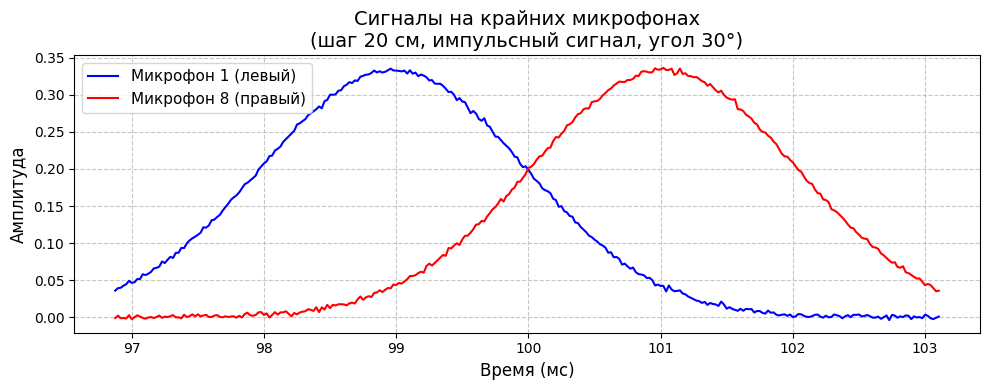

  Пик микрофона 1: 98.958 мс
  Пик микрофона 8: 101.021 мс
  Разница: 2.063 мс


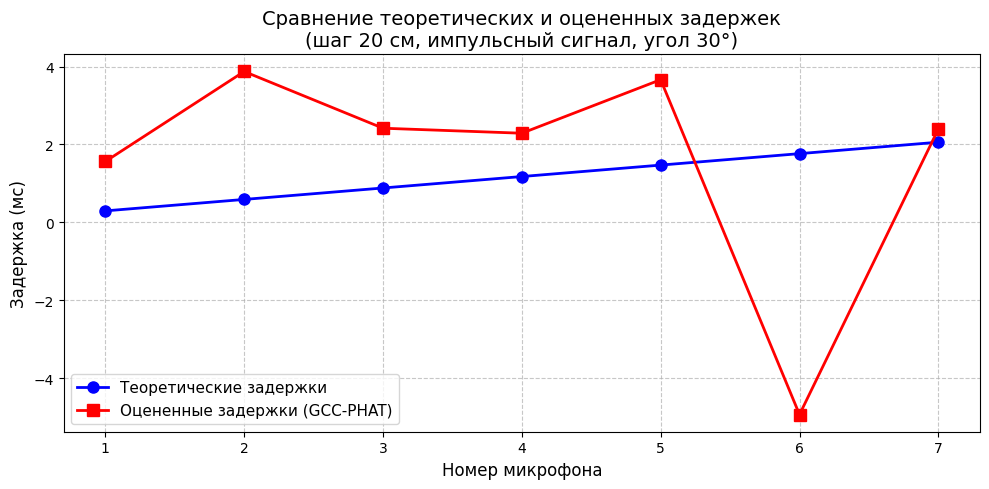


Данные для рисунка:
  Истинная задержка: 2.059 мс
  Найденный пик: 2.396 мс
  Ошибка пика: 0.337 мс


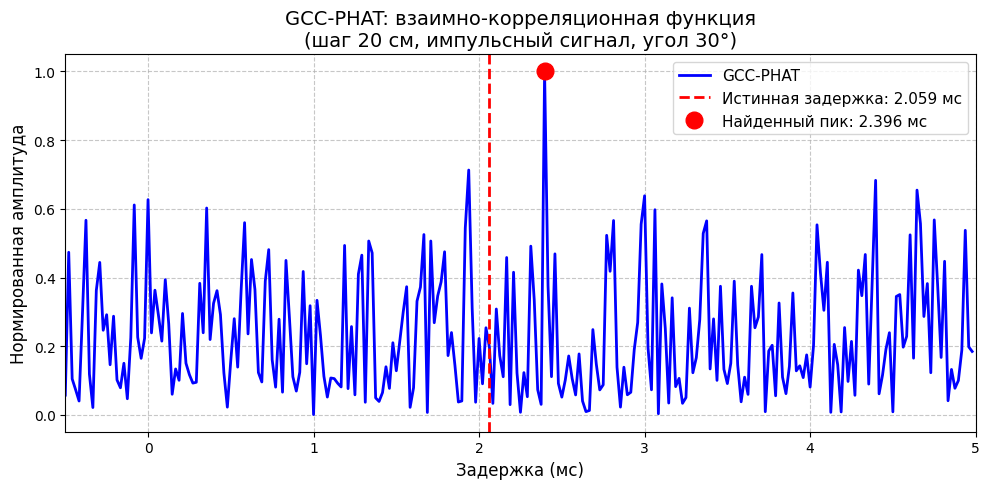

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import rfft, irfft

np.random.seed(42)

# 1. Генерация импульсного сигнала

def generate_impulse_signal(fs, T, t0=0.1, sigma=0.001):
    """Генерация гауссова импульса (щелчка)"""
    t = np.arange(0, T, 1/fs)
    s = np.exp(-(t - t0)**2 / (2 * sigma**2))
    s = s / np.max(s)
    return t, s

def generate_array_signals(s, t, d, theta, R=3.0, SNR_dB=30, c=340, fs=None):
    M = len(d)
    L = len(s)
    theta_rad = np.deg2rad(theta)
    tau = d * np.sin(theta_rad) / c

    tau_samples = tau * fs
    delay_samples = np.round(tau_samples).astype(int)

    attenuation = 1.0 / R
    X = np.zeros((M, L))

    for m in range(M):
        s_delayed = np.zeros_like(s)
        delay = delay_samples[m]

        if delay >= 0:
            if delay > 0:
                s_delayed[delay:] = s[:-delay]
            else:
                s_delayed[:] = s[:]
        else:
            delay_abs = abs(delay)
            if delay_abs > 0:
                s_delayed[:-delay_abs] = s[delay_abs:]
            else:
                s_delayed[:] = s[:]

        signal_power = np.mean(s_delayed**2)
        if signal_power < 1e-12:
            signal_power = 1.0
        noise_power = signal_power / (10**(SNR_dB/10))
        noise = np.sqrt(noise_power) * np.random.randn(L)

        X[m, :] = attenuation * s_delayed + noise

    return X, tau

# 2. GCC-PHAT

def gcc_phat_interp(signal1, signal2, fs, max_delay_ms=5):
    signal1 = np.nan_to_num(signal1, nan=0.0)
    signal2 = np.nan_to_num(signal2, nan=0.0)

    X1 = rfft(signal1)
    X2 = rfft(signal2)

    G = X1 * np.conj(X2)
    magnitude = np.abs(G)
    magnitude = np.maximum(magnitude, 1e-12)
    G_phat = G / magnitude

    corr = irfft(G_phat)

    max_delay_samples = int(max_delay_ms * fs / 1000)
    center = len(corr) // 2
    start = max(0, center - max_delay_samples)
    end = min(len(corr), center + max_delay_samples)

    search_range = corr[start:end]

    if len(search_range) == 0:
        return 0.0, corr

    max_index = np.argmax(np.abs(search_range)) + start

    if 1 < max_index < len(corr) - 1:
        y0 = np.abs(corr[max_index - 1])
        y1 = np.abs(corr[max_index])
        y2 = np.abs(corr[max_index + 1])
        denom = y0 - 2*y1 + y2
        if abs(denom) > 1e-12:
            offset = (y0 - y2) / (2 * denom)
            if abs(offset) < 1:
                max_index_interp = max_index + offset
            else:
                max_index_interp = max_index
        else:
            max_index_interp = max_index
    else:
        max_index_interp = max_index

    tau = (max_index_interp - center) / fs
    return tau, corr

# 3. Оценка задержек

def estimate_delays(X, fs, max_delay_ms=5):
    M = X.shape[0]
    delays = np.zeros(M)
    for m in range(1, M):
        tau, _ = gcc_phat_interp(X[0, :], X[m, :], fs, max_delay_ms)
        delays[m] = tau
    return delays

# 4. Параметры

fs = 48000
T = 0.5
M = 8
delta_d = 0.20
theta_true = 30
R = 3.0
SNR_dB = 30
c = 340

print("ИМПУЛЬСНЫЙ СИГНАЛ")
print(f"  Шаг решетки: {delta_d*100:.0f} см")
print(f"  Сигнал: импульсный (щелчок)")
print(f"  Угол источника: {theta_true}°")
print(f"  SNR: {SNR_dB} дБ")

# координаты микрофонов
d = (np.arange(M) - (M - 1) / 2) * delta_d
print(f"Координаты микрофонов: {d}")

# генерация сигналов
t, s = generate_impulse_signal(fs, T, t0=0.1, sigma=0.001)
X, tau_true = generate_array_signals(s, t, d, theta_true, R, SNR_dB, fs=fs, c=c)

print(f"Размерность X: {X.shape}")
print(f"Теоретическая задержка (крайние): {tau_true[-1] - tau_true[0]:.6f} с")

# оценка задержек
delays = estimate_delays(X, fs, max_delay_ms=5)

# теоретические задержки относительно первого микрофона
true_delays = tau_true - tau_true[0]

# 5. Численные результаты (таблица)

print("СРАВНЕНИЕ ТЕОРЕТИЧЕСКИХ И ОЦЕНЕННЫХ ЗАДЕРЖЕК")

print(f"{'Микрофон':<10} {'Теоретическая (мс)':<20} {'Оцененная (мс)':<20} {'Ошибка (мс)':<15}")

errors = []
for m in range(1, M):
    true_ms = true_delays[m] * 1000
    est_ms = delays[m] * 1000
    error_ms = abs(true_ms - est_ms)
    errors.append(error_ms)
    print(f"{m+1:<10} {true_ms:<20.4f} {est_ms:<20.4f} {error_ms:<15.4f}")

print(f"Средняя ошибка: {np.mean(errors):.4f} мс")
print(f"Максимальная ошибка: {np.max(errors):.4f} мс")

# 6. Оценка угла

delta_tau = delays[-1] - delays[0]
L = (M - 1) * delta_d
sin_theta_est = c * delta_tau / L
sin_theta_est = np.clip(sin_theta_est, -1.0, 1.0)
theta_est = np.rad2deg(np.arcsin(sin_theta_est))

print(f"\nОЦЕНКА УГЛА:")
print(f"  Истинный угол: {theta_true}°")
print(f"  Оцененный угол: {theta_est:.2f}°")
print(f"  Ошибка: {abs(theta_est - theta_true):.2f}°")

# 7. РИС. Сигналы на крайних микрофонах

plt.figure(figsize=(10, 4))

# ищем импульсы (пики)
peak_mic1 = np.argmax(np.abs(X[0, :])) / fs * 1000
peak_mic8 = np.argmax(np.abs(X[7, :])) / fs * 1000

# показываем участок вокруг импульса
t0_samples = int(0.1 * fs)
n_before = 150
n_after = 150
start = t0_samples - n_before
end = t0_samples + n_after

time_ms = t[start:end] * 1000

plt.plot(time_ms, X[0, start:end], 'b-', linewidth=1.5, label='Микрофон 1 (левый)')
plt.plot(time_ms, X[7, start:end], 'r-', linewidth=1.5, label='Микрофон 8 (правый)')

plt.xlabel('Время (мс)', fontsize=12)
plt.ylabel('Амплитуда', fontsize=12)
plt.title('Сигналы на крайних микрофонах\n(шаг 20 см, импульсный сигнал, угол 30°)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"  Пик микрофона 1: {peak_mic1:.3f} мс")
print(f"  Пик микрофона 8: {peak_mic8:.3f} мс")
print(f"  Разница: {peak_mic8 - peak_mic1:.3f} мс")

# 8. РИС. Сравнение задержек

plt.figure(figsize=(10, 5))

plt.plot(range(1, M), true_delays[1:] * 1000, 'o-',
         color='blue', linewidth=2, markersize=8, label='Теоретические задержки')

plt.plot(range(1, M), delays[1:] * 1000, 's-',
         color='red', linewidth=2, markersize=8, label='Оцененные задержки (GCC-PHAT)')

plt.xlabel('Номер микрофона', fontsize=12)
plt.ylabel('Задержка (мс)', fontsize=12)
plt.title('Сравнение теоретических и оцененных задержек\n(шаг 20 см, импульсный сигнал, угол 30°)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 9. РИС. Взаимно-корреляционная функция

corr = gcc_phat_interp(X[0, :], X[7, :], fs, max_delay_ms=5)[1]

tau_range_full = np.arange(len(corr)) / fs * 1000
center = len(corr) // 2

max_delay_ms = 5
max_delay_samples = int(max_delay_ms * fs / 1000)
start_corr = center - max_delay_samples
end_corr = center + max_delay_samples

corr_cut = np.abs(corr[start_corr:end_corr])
tau_cut = tau_range_full[start_corr:end_corr] - tau_range_full[center]

corr_cut = corr_cut / np.max(corr_cut)

true_tau = (tau_true[-1] - tau_true[0]) * 1000

mask = (tau_cut > 0.5) & (tau_cut < 5)
corr_masked = corr_cut[mask]
tau_masked = tau_cut[mask]

if len(corr_masked) > 0 and np.max(corr_masked) > 0.01:
    max_idx = np.argmax(corr_masked)
    max_tau = tau_masked[max_idx]
    max_val = corr_masked[max_idx]
else:
    max_idx = np.argmax(corr_cut)
    max_tau = tau_cut[max_idx]
    max_val = corr_cut[max_idx]

print(f"\nДанные для рисунка:")
print(f"  Истинная задержка: {true_tau:.3f} мс")
print(f"  Найденный пик: {max_tau:.3f} мс")
print(f"  Ошибка пика: {abs(max_tau - true_tau):.3f} мс")

plt.figure(figsize=(10, 5))

plt.plot(tau_cut, corr_cut, 'b-', linewidth=2, label='GCC-PHAT')

plt.axvline(true_tau, color='r', linestyle='--', linewidth=2,
            label=f'Истинная задержка: {true_tau:.3f} мс')

plt.plot(max_tau, max_val, 'ro', markersize=12,
         label=f'Найденный пик: {max_tau:.3f} мс')

plt.xlabel('Задержка (мс)', fontsize=12)
plt.ylabel('Нормированная амплитуда', fontsize=12)
plt.title('GCC-PHAT: взаимно-корреляционная функция\n(шаг 20 см, импульсный сигнал, угол 30°)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(-0.5, 5)
plt.tight_layout()
plt.show()